# Retail Demand Forecasting & Inventory Optimisation

**End-to-end retail decision system: forecast SKU demand, quantify uncertainty, and convert forecasts into replenishment targets.**

### Business questions
1. What will each high-volume SKU sell next?
2. Does machine learning beat a seasonal-naive forecast?
3. Which products create the largest forecast errors and stock-out risk?
4. How much safety stock is justified by forecast uncertainty?
5. Can a forecast-driven policy reduce simulated stock-outs without excessive inventory?

### Real dataset
This notebook uses the **UCI Online Retail** dataset: 541,909 transactions from a UK-based online retailer between December 2010 and December 2011.

### Modelling stack
- strict chronological train / validation / test split
- lagged and rolling demand features
- seasonal-naive baseline
- Extra Trees regression
- XGBoost regression
- WMAPE, MAE and RMSE evaluation
- feature importance + SHAP
- 7-day inventory simulation
- safety stock and reorder-point recommendations

Customer identifiers are not used in the forecasting model.

In [1]:
# Colab / GitHub Actions safe setup
import sys, subprocess, importlib.util

required = {
    "openpyxl": "openpyxl",
    "xgboost": "xgboost",
    "shap": "shap"
}
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Environment ready.")

Environment ready.


In [2]:
import warnings, zipfile, urllib.request
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported.")

Libraries imported.


## 1. Download the real UCI Online Retail dataset

The source file is downloaded directly from the UCI Machine Learning Repository. No synthetic sales data is used.

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
zip_path = Path("online_retail.zip")
extract_dir = Path("online_retail_data")

if not zip_path.exists():
    urllib.request.urlretrieve(DATA_URL, zip_path)

extract_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

xlsx_files = list(extract_dir.rglob("*.xlsx"))
if not xlsx_files:
    raise FileNotFoundError("UCI Online Retail Excel file was not found.")

raw = pd.read_excel(xlsx_files[0], engine="openpyxl")

print(f"Raw rows: {len(raw):,}")
print(f"Columns: {raw.columns.tolist()}")
print(f"Date range: {raw['InvoiceDate'].min()} -> {raw['InvoiceDate'].max()}")
display(raw.head())

Raw rows: 541,909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,"17,850.000",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,"17,850.000",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom


## 2. Retail data quality and transaction cleaning

Cancellations, returns, non-positive prices, missing product descriptions and non-product administrative stock codes are removed before demand modelling.

In [4]:
df = raw.copy()

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

clean = df.loc[
    ~df["InvoiceNo"].str.upper().str.startswith("C")
    & df["InvoiceDate"].notna()
    & df["Description"].notna()
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
    & (df["Country"] == "United Kingdom")
].copy()

# Keep standard merchandise stock codes; remove postage/manual adjustment rows.
clean = clean.loc[clean["StockCode"].str.match(r"^\d{5}[A-Z]?$", na=False)].copy()
clean["date"] = clean["InvoiceDate"].dt.floor("D")
clean["revenue"] = clean["Quantity"] * clean["UnitPrice"]

print(f"Clean UK merchandise rows: {len(clean):,}")
print(f"Unique products: {clean['StockCode'].nunique():,}")
print(f"Positive units sold: {int(clean['Quantity'].sum()):,}")
print(f"Observed revenue: £{clean['revenue'].sum():,.2f}")
print(f"CustomerID used as a model feature: {'CustomerID' in []}")

quality = pd.DataFrame({
    "missing": clean.isna().sum(),
    "unique": clean.nunique(dropna=False)
})
display(quality)

Clean UK merchandise rows: 481,770
Unique products: 3,782
Positive units sold: 4,646,942
Observed revenue: £8,703,448.62
CustomerID used as a model feature: False


,missing,unique
InvoiceNo,0,17897
StockCode,0,3782
Description,0,3983
Quantity,0,368
InvoiceDate,0,16693
UnitPrice,0,495
CustomerID,128014,3917
Country,0,1
date,0,305
revenue,0,4029


## 3. Select consistently replenished SKUs and create a complete daily demand panel

A raw “top-selling” list can be dominated by one-off bulk purchases. For forecasting and replenishment, this notebook focuses on **high-volume products with repeat demand**:
- at least 180 active selling days;
- no single day contributing more than 15% of annual units.

This makes the forecasting task closer to genuine replenishment planning rather than predicting exceptional wholesale orders.

In [5]:
description_map = (
    clean.groupby("StockCode")["Description"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
)

all_daily = (
    clean.groupby(["date","StockCode"], as_index=False)
    .agg(
        demand=("Quantity","sum"),
        revenue=("revenue","sum"),
        median_price=("UnitPrice","median")
    )
)

sku_stats = (
    all_daily.groupby("StockCode")
    .agg(
        total_units=("demand","sum"),
        active_days=("date","nunique"),
        max_daily_units=("demand","max"),
        mean_active_day_units=("demand","mean")
    )
)
sku_stats["max_day_share"] = (
    sku_stats["max_daily_units"] / sku_stats["total_units"].clip(lower=1)
)

eligible_skus = sku_stats.loc[
    (sku_stats["active_days"] >= 180)
    & (sku_stats["max_day_share"] <= 0.15)
].copy()

top_codes = (
    eligible_skus.sort_values("total_units", ascending=False)
    .head(20)
    .index
)

daily = all_daily.loc[all_daily["StockCode"].isin(top_codes)].copy()

all_dates = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
grid = pd.MultiIndex.from_product(
    [all_dates, top_codes],
    names=["date","StockCode"]
).to_frame(index=False)

panel = grid.merge(daily, on=["date","StockCode"], how="left")
panel["demand"] = panel["demand"].fillna(0.0)
panel["revenue"] = panel["revenue"].fillna(0.0)

product_median_price = clean.groupby("StockCode")["UnitPrice"].median()
panel["median_price"] = (
    panel["median_price"]
    .fillna(panel["StockCode"].map(product_median_price))
)

panel["Description"] = panel["StockCode"].map(description_map)

product_summary = (
    panel.groupby(["StockCode","Description"])
    .agg(
        total_units=("demand","sum"),
        active_days=("demand", lambda s: int((s > 0).sum())),
        avg_daily_units=("demand","mean"),
        demand_std=("demand","std"),
        max_daily_units=("demand","max")
    )
    .sort_values("total_units", ascending=False)
)
product_summary["max_day_share"] = (
    product_summary["max_daily_units"]
    / product_summary["total_units"].clip(lower=1)
)

print(f"Eligible consistently-selling SKUs: {len(eligible_skus):,}")
print(f"Daily panel rows: {len(panel):,}")
print(f"Products modelled: {panel['StockCode'].nunique()}")
print(f"Days modelled: {panel['date'].nunique()}")
print("Selection rule: active_days >= 180 and max_day_share <= 15%")
display(product_summary.head(10))

Eligible consistently-selling SKUs: 292
Daily panel rows: 7,480
Products modelled: 20
Days modelled: 374
Selection rule: active_days >= 180 and max_day_share <= 15%


,,total_units,active_days,avg_daily_units,demand_std,max_daily_units,max_day_share
StockCode,Description,,,,,,
22197,POPCORN HOLDER,"53,343.000",291,142.628,373.246,"4,314.000",0.081
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"49,526.000",223,132.422,391.714,"4,848.000",0.098
85099B,JUMBO BAG RED RETROSPOT,"44,264.000",300,118.353,175.478,"1,533.000",0.035
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"35,509.000",305,94.944,222.425,"3,114.000",0.088
84879,ASSORTED COLOUR BIRD ORNAMENT,"33,735.000",298,90.201,206.219,"3,359.000",0.100
22616,PACK OF 12 LONDON TISSUES,"25,127.000",236,67.184,187.861,"1,321.000",0.053
21212,PACK OF 72 RETROSPOT CAKE CASES,"24,986.000",294,66.807,130.030,"1,345.000",0.054
22178,VICTORIAN GLASS HANGING T-LIGHT,"23,692.000",288,63.348,101.206,986.000,0.042
15036,ASSORTED COLOURS SILK FAN,"21,066.000",228,56.326,176.222,"1,846.000",0.088


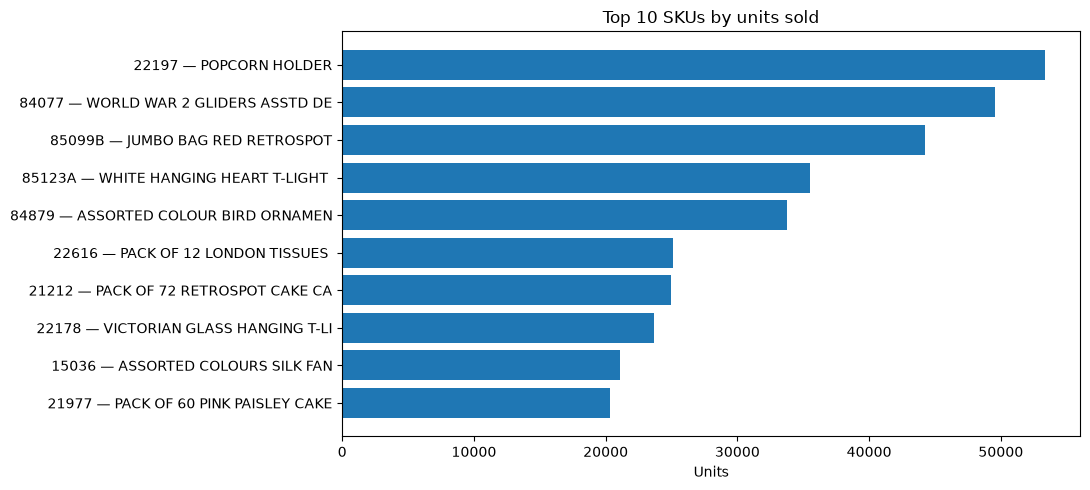

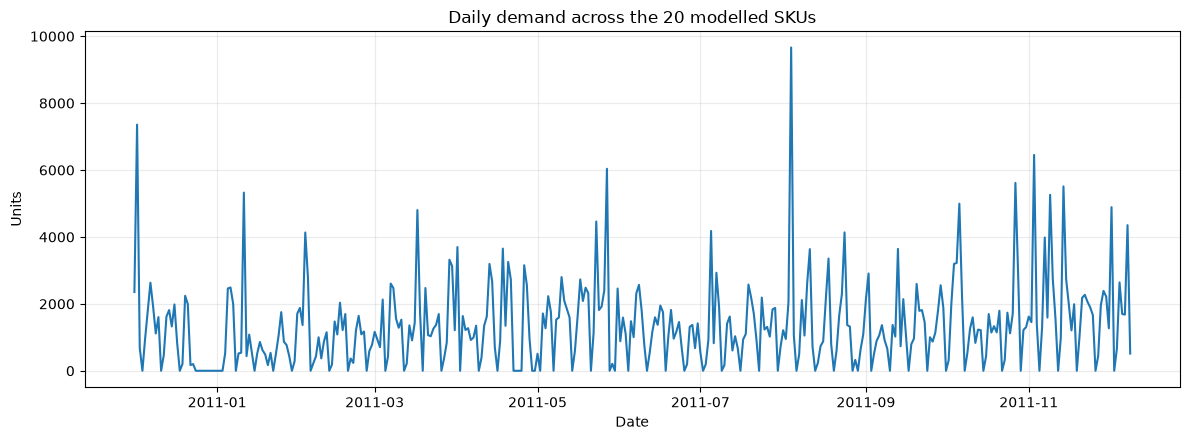

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
top10 = product_summary.head(10).sort_values("total_units")
ax.barh(
    [f"{idx[0]} — {idx[1][:28]}" for idx in top10.index],
    top10["total_units"]
)
ax.set_title("Top 10 SKUs by units sold")
ax.set_xlabel("Units")
plt.tight_layout()
plt.show()

daily_total = panel.groupby("date")["demand"].sum()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily_total.index, daily_total.values)
ax.set_title("Daily demand across the 20 modelled SKUs")
ax.set_ylabel("Units")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Leakage-safe demand features

Every demand feature is shifted, so it uses only information that existed **before** the day being predicted.

In [7]:
panel = panel.sort_values(["StockCode","date"]).reset_index(drop=True)

g = panel.groupby("StockCode", group_keys=False)

for lag in [1, 2, 7, 14, 28]:
    panel[f"lag_{lag}"] = g["demand"].shift(lag)

for window in [7, 14, 28]:
    panel[f"rolling_mean_{window}"] = g["demand"].transform(
        lambda s: s.shift(1).rolling(window).mean()
    )
    panel[f"rolling_std_{window}"] = g["demand"].transform(
        lambda s: s.shift(1).rolling(window).std()
    )

panel["zero_demand_rate_28"] = g["demand"].transform(
    lambda s: s.shift(1).rolling(28).apply(lambda x: np.mean(x == 0), raw=True)
)
panel["lag_price_1"] = g["median_price"].shift(1)

panel["dow"] = panel["date"].dt.dayofweek
panel["week"] = panel["date"].dt.isocalendar().week.astype(int)
panel["month"] = panel["date"].dt.month
panel["day_of_month"] = panel["date"].dt.day
panel["is_weekend"] = (panel["dow"] >= 5).astype(int)
panel["dow_sin"] = np.sin(2*np.pi*panel["dow"]/7)
panel["dow_cos"] = np.cos(2*np.pi*panel["dow"]/7)
panel["month_sin"] = np.sin(2*np.pi*panel["month"]/12)
panel["month_cos"] = np.cos(2*np.pi*panel["month"]/12)

model_df = panel.dropna().copy()

print(f"Rows after lag/rolling warm-up: {len(model_df):,}")
print("Forecast target: demand")
print("All demand history variables are shifted by at least one day.")

Rows after lag/rolling warm-up: 6,920
Forecast target: demand
All demand history variables are shifted by at least one day.


## 5. Strict chronological train / validation / test design

The final 60 days are held out for testing. The preceding 45 days are validation data used for model selection.

In [8]:
max_date = model_df["date"].max()
test_start = max_date - pd.Timedelta(days=59)
val_start = test_start - pd.Timedelta(days=45)

train_df = model_df.loc[model_df["date"] < val_start].copy()
val_df = model_df.loc[
    (model_df["date"] >= val_start) & (model_df["date"] < test_start)
].copy()
test_df = model_df.loc[model_df["date"] >= test_start].copy()

numeric_features = [
    "lag_1","lag_2","lag_7","lag_14","lag_28",
    "rolling_mean_7","rolling_mean_14","rolling_mean_28",
    "rolling_std_7","rolling_std_14","rolling_std_28",
    "zero_demand_rate_28","lag_price_1",
    "dow","week","month","day_of_month","is_weekend",
    "dow_sin","dow_cos","month_sin","month_cos"
]

def make_matrix(frame):
    base = frame[numeric_features + ["StockCode"]].copy()
    return pd.get_dummies(base, columns=["StockCode"], prefix="sku", dtype=float)

X_all = make_matrix(model_df)
all_columns = X_all.columns.tolist()

def matrix_for(frame):
    return make_matrix(frame).reindex(columns=all_columns, fill_value=0.0)

X_train, y_train = matrix_for(train_df), train_df["demand"].astype(float)
X_val, y_val = matrix_for(val_df), val_df["demand"].astype(float)
X_test, y_test = matrix_for(test_df), test_df["demand"].astype(float)

split_summary = pd.DataFrame({
    "rows":[len(train_df),len(val_df),len(test_df)],
    "start":[train_df["date"].min(),val_df["date"].min(),test_df["date"].min()],
    "end":[train_df["date"].max(),val_df["date"].max(),test_df["date"].max()],
    "units":[y_train.sum(),y_val.sum(),y_test.sum()]
}, index=["train","validation","test"])

display(split_summary)
print(f"Feature columns after SKU encoding: {len(all_columns)}")

,rows,start,end,units
train,4820,2010-12-29,2011-08-26,"304,998.000"
validation,900,2011-08-27,2011-10-10,"58,856.000"
test,1200,2011-10-11,2011-12-09,"106,010.000"


Feature columns after SKU encoding: 42


## 6. Train forecasting models and create a SKU-level champion strategy

Different products have different demand dynamics. A single global model is not automatically best for every SKU.

The validation set therefore chooses the best forecaster **independently for each SKU** from:
- seasonal naive (same weekday last week);
- Extra Trees;
- XGBoost.

That per-SKU champion mapping is then frozen before the final test period.

In [9]:
extra = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
extra.fit(X_train, y_train)

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.035,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_lambda=2.0,
    reg_alpha=0.05,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

val_pred_extra = np.clip(extra.predict(X_val), 0, None)
val_pred_xgb = np.clip(xgb.predict(X_val), 0, None)
val_pred_naive = np.clip(val_df["lag_7"].to_numpy(), 0, None)

print("Models trained.")

Models trained.


,MAE,RMSE,WMAPE,forecast_bias
model,,,,
SKU champion ensemble,60.27,132.88,92.16%,-0.74%
Extra Trees,67.33,137.18,102.96%,23.45%
Seasonal naive (lag 7),71.34,161.79,109.08%,-6.91%
XGBoost,74.01,141.26,113.18%,34.06%


Frozen validation-selected champions:


,SKU count
Extra Trees,12
Seasonal naive,6
XGBoost,2


Deployment strategy: SKU champion ensemble


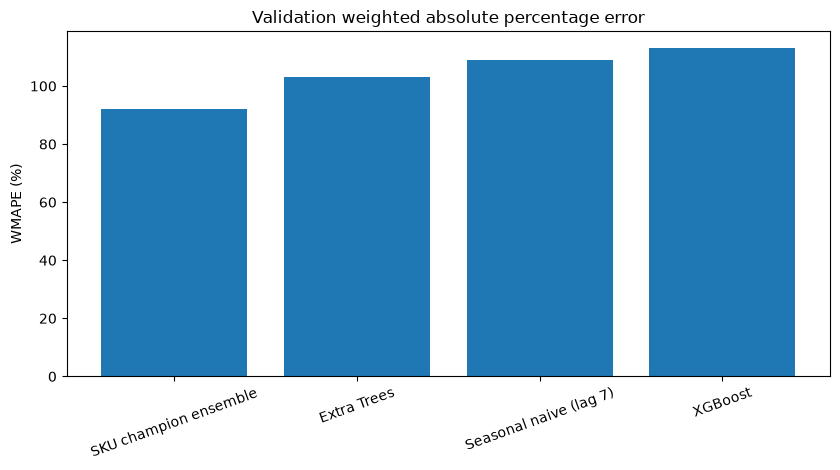

In [10]:
def forecast_metrics(name, y_true, pred):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(pred, dtype=float)
    mae = mean_absolute_error(y, p)
    rmse = mean_squared_error(y, p) ** 0.5
    wmape = np.abs(y-p).sum() / max(np.abs(y).sum(), 1e-12)
    bias = (p-y).sum() / max(y.sum(), 1e-12)
    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "WMAPE": wmape,
        "forecast_bias": bias
    }

# Validation-only model selection by SKU.
val_compare = val_df[["StockCode","demand"]].copy()
val_compare["Seasonal naive"] = val_pred_naive
val_compare["Extra Trees"] = val_pred_extra
val_compare["XGBoost"] = val_pred_xgb

def sku_wmape(group, col):
    return (
        np.abs(group["demand"] - group[col]).sum()
        / max(np.abs(group["demand"]).sum(), 1e-12)
    )

sku_model_scores = pd.DataFrame({
    model: val_compare.groupby("StockCode").apply(
        lambda g, m=model: sku_wmape(g, m),
        include_groups=False
    )
    for model in ["Seasonal naive","Extra Trees","XGBoost"]
})

champion_by_sku = sku_model_scores.idxmin(axis=1)

def apply_champions(frame, pred_naive, pred_extra, pred_xgb):
    out = np.zeros(len(frame), dtype=float)
    naive_arr = np.asarray(pred_naive)
    extra_arr = np.asarray(pred_extra)
    xgb_arr = np.asarray(pred_xgb)

    for i, sku in enumerate(frame["StockCode"].values):
        champion = champion_by_sku.loc[sku]
        if champion == "Seasonal naive":
            out[i] = naive_arr[i]
        elif champion == "Extra Trees":
            out[i] = extra_arr[i]
        else:
            out[i] = xgb_arr[i]
    return out

val_pred_champion = apply_champions(
    val_df, val_pred_naive, val_pred_extra, val_pred_xgb
)

val_results = pd.DataFrame([
    forecast_metrics("Seasonal naive (lag 7)", y_val, val_pred_naive),
    forecast_metrics("Extra Trees", y_val, val_pred_extra),
    forecast_metrics("XGBoost", y_val, val_pred_xgb),
    forecast_metrics("SKU champion ensemble", y_val, val_pred_champion)
]).set_index("model").sort_values("WMAPE")

display(val_results.style.format({
    "MAE":"{:.2f}","RMSE":"{:.2f}",
    "WMAPE":"{:.2%}","forecast_bias":"{:.2%}"
}))

print("Frozen validation-selected champions:")
display(champion_by_sku.value_counts().rename("SKU count").to_frame())

print("Deployment strategy: SKU champion ensemble")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_df = val_results.sort_values("WMAPE")
ax.bar(plot_df.index, plot_df["WMAPE"] * 100)
ax.set_title("Validation weighted absolute percentage error")
ax.set_ylabel("WMAPE (%)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 7. One-time final test evaluation

In [11]:
test_pred_extra = np.clip(extra.predict(X_test), 0, None)
test_pred_xgb = np.clip(xgb.predict(X_test), 0, None)
test_pred_naive = np.clip(test_df["lag_7"].to_numpy(), 0, None)

test_pred_champion = apply_champions(
    test_df, test_pred_naive, test_pred_extra, test_pred_xgb
)
test_pred_best = test_pred_champion
best_ml_name = "SKU champion ensemble"

test_results = pd.DataFrame([
    forecast_metrics("Seasonal naive (lag 7)", y_test, test_pred_naive),
    forecast_metrics("Extra Trees", y_test, test_pred_extra),
    forecast_metrics("XGBoost", y_test, test_pred_xgb),
    forecast_metrics("SKU champion ensemble", y_test, test_pred_champion)
]).set_index("model").sort_values("WMAPE")

display(test_results.style.format({
    "MAE":"{:.2f}","RMSE":"{:.2f}",
    "WMAPE":"{:.2%}","forecast_bias":"{:.2%}"
}))

selected_test = test_results.loc[best_ml_name]
baseline_test = test_results.loc["Seasonal naive (lag 7)"]

print(f"""
FINAL FORECAST RESULT
---------------------
Deployment strategy: {best_ml_name}
Test MAE: {selected_test['MAE']:.2f} units / SKU-day
Test RMSE: {selected_test['RMSE']:.2f}
Test WMAPE: {selected_test['WMAPE']:.2%}
Seasonal-naive WMAPE: {baseline_test['WMAPE']:.2%}
WMAPE change vs naive: {(selected_test['WMAPE']/baseline_test['WMAPE']-1):+.2%}
Forecast bias: {selected_test['forecast_bias']:.2%}
""")

,MAE,RMSE,WMAPE,forecast_bias
model,,,,
SKU champion ensemble,80.99,239.67,91.68%,-16.06%
Extra Trees,81.96,236.53,92.77%,-15.21%
XGBoost,92.72,237.84,104.96%,9.20%
Seasonal naive (lag 7),100.63,307.71,113.91%,3.68%



FINAL FORECAST RESULT
---------------------
Deployment strategy: SKU champion ensemble
Test MAE: 80.99 units / SKU-day
Test RMSE: 239.67
Test WMAPE: 91.68%
Seasonal-naive WMAPE: 113.91%
WMAPE change vs naive: -19.51%
Forecast bias: -16.06%



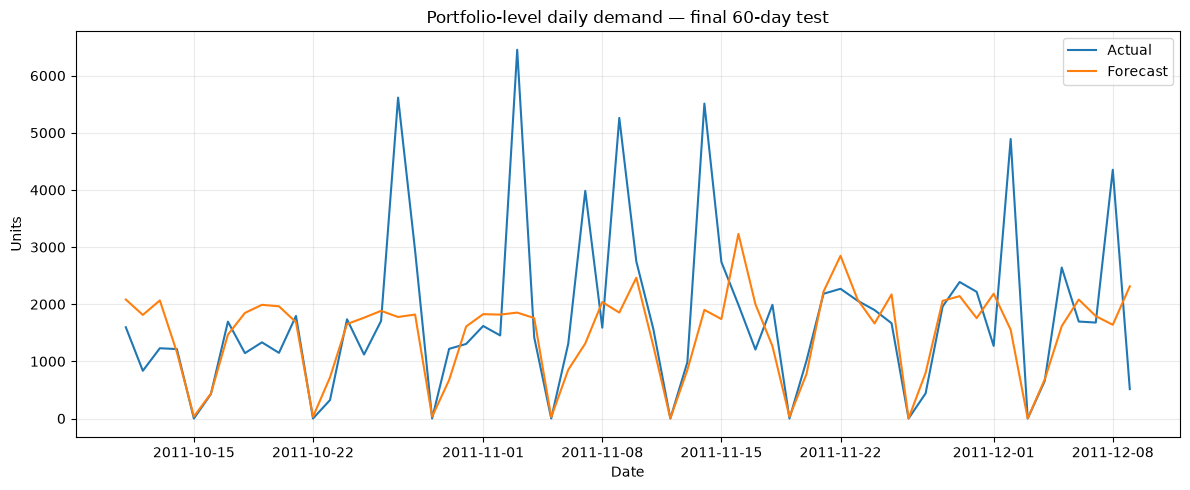

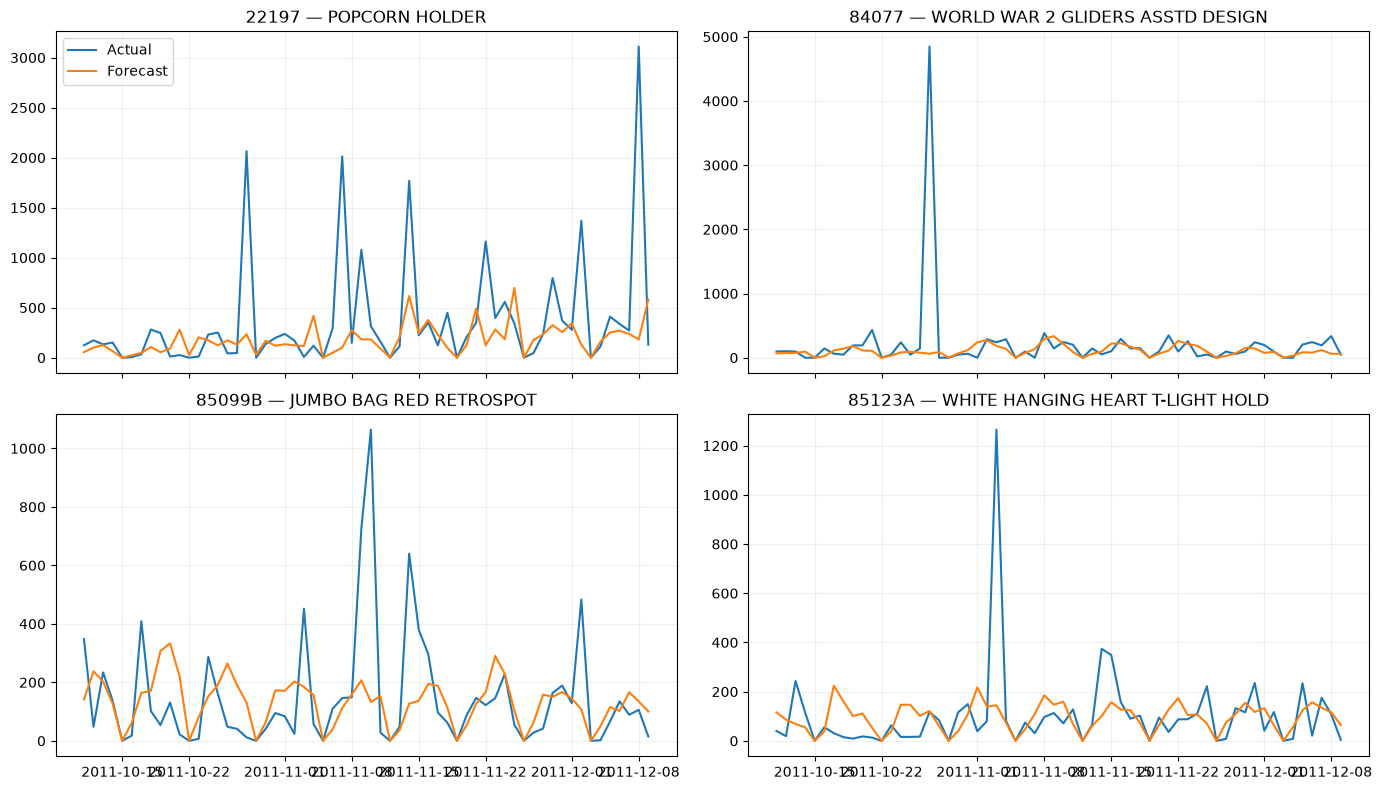

In [12]:
test_plot = test_df[["date","StockCode","Description","demand"]].copy()
test_plot["prediction"] = test_pred_best

actual_total = test_plot.groupby("date")["demand"].sum()
pred_total = test_plot.groupby("date")["prediction"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual_total.index, actual_total.values, label="Actual")
ax.plot(pred_total.index, pred_total.values, label="Forecast")
ax.set_title("Portfolio-level daily demand — final 60-day test")
ax.set_ylabel("Units")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

top4_codes = product_summary.head(4).index.get_level_values(0).tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, sku in zip(axes.ravel(), top4_codes):
    d = test_plot.loc[test_plot["StockCode"] == sku]
    desc = d["Description"].iloc[0][:32]
    ax.plot(d["date"], d["demand"], label="Actual")
    ax.plot(d["date"], d["prediction"], label="Forecast")
    ax.set_title(f"{sku} — {desc}")
    ax.grid(alpha=0.2)
axes[0,0].legend()
plt.tight_layout()
plt.show()

## 8. Explainability — what drives the ML component of the champion system?

The operational forecast is a per-SKU champion ensemble. XGBoost remains an important component, so its feature importance and SHAP values are inspected to understand the machine-learning demand signal.

,importance
SKU identity,0.291
is_weekend,0.104
dow,0.039
lag_14,0.038
rolling_std_7,0.035
lag_2,0.034
dow_cos,0.033
rolling_mean_14,0.032
rolling_std_14,0.032
rolling_std_28,0.032


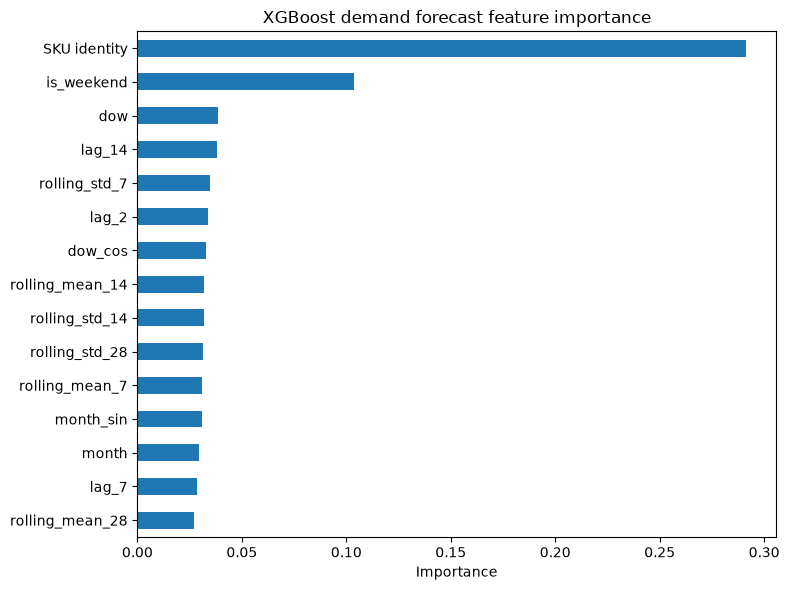

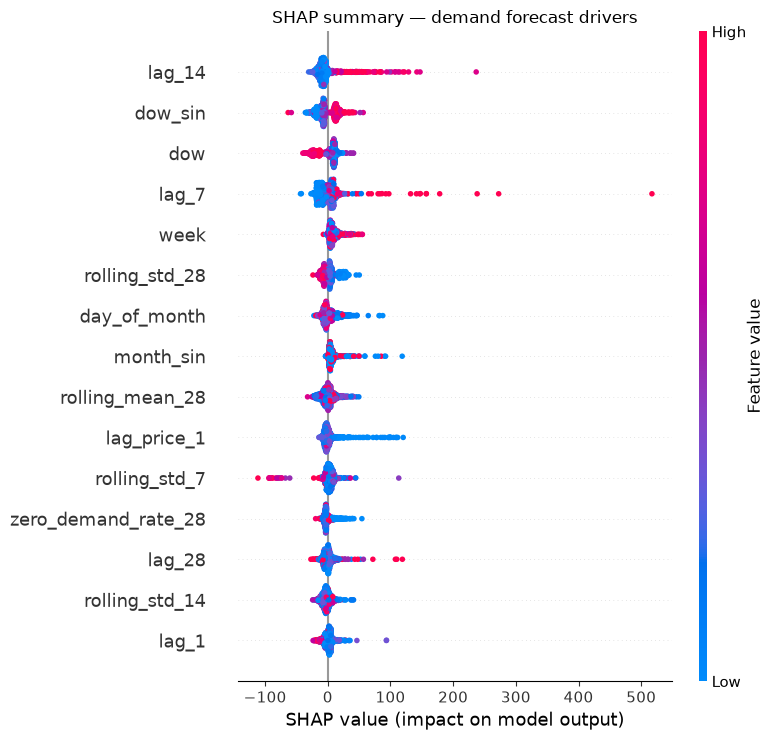

In [13]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Aggregate all SKU dummy importances into one readable family.
readable = {}
for feature, value in xgb_importance.items():
    key = "SKU identity" if feature.startswith("sku_") else feature
    readable[key] = readable.get(key, 0.0) + float(value)

readable_importance = pd.Series(readable).sort_values(ascending=False).head(15)
display(readable_importance.to_frame("importance"))

fig, ax = plt.subplots(figsize=(8, 6))
readable_importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("XGBoost demand forecast feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

import shap
sample_for_shap = X_val.sample(min(1000, len(X_val)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample_for_shap)
shap.summary_plot(shap_values, sample_for_shap, max_display=15, show=False)
plt.title("SHAP summary — demand forecast drivers")
plt.tight_layout()
plt.show()

## 9. Convert forecast uncertainty into safety stock

Inventory assumptions are explicit and illustrative:
- 7-day supplier lead time
- 95% cycle-service target
- safety stock based on validation residual uncertainty

This is an inventory policy simulation, not a claim about the retailer's actual stock levels.

In [14]:
LEAD_TIME_DAYS = 7
SERVICE_Z = 1.645

val_policy = val_df[["date","StockCode","demand","rolling_mean_7"]].copy()
val_policy["prediction"] = val_pred_champion
val_policy["residual"] = val_policy["demand"] - val_policy["prediction"]

resid_std = (
    val_policy.groupby("StockCode")["residual"]
    .std()
    .fillna(val_policy["residual"].std())
)

policy = test_df[[
    "date","StockCode","Description","demand","rolling_mean_7"
]].copy()
policy["forecast"] = test_pred_best
policy["residual_std"] = policy["StockCode"].map(resid_std).fillna(resid_std.mean())
policy["safety_stock"] = (
    SERVICE_Z * policy["residual_std"] * np.sqrt(LEAD_TIME_DAYS)
)
policy["recommended_target"] = (
    policy["forecast"] * LEAD_TIME_DAYS + policy["safety_stock"]
)
policy["baseline_target"] = (
    policy["rolling_mean_7"].clip(lower=0) * LEAD_TIME_DAYS
)

# Actual demand over the next 7 days, used only for retrospective simulation.
policy = policy.sort_values(["StockCode","date"]).reset_index(drop=True)
policy["actual_7d_demand"] = (
    policy.groupby("StockCode")["demand"]
    .transform(lambda s: s.iloc[::-1].rolling(LEAD_TIME_DAYS, min_periods=LEAD_TIME_DAYS).sum().iloc[::-1])
)

sim = policy.dropna(subset=["actual_7d_demand"]).copy()

sim["baseline_shortage"] = np.maximum(
    sim["actual_7d_demand"] - sim["baseline_target"], 0
)
sim["recommended_shortage"] = np.maximum(
    sim["actual_7d_demand"] - sim["recommended_target"], 0
)
sim["baseline_excess"] = np.maximum(
    sim["baseline_target"] - sim["actual_7d_demand"], 0
)
sim["recommended_excess"] = np.maximum(
    sim["recommended_target"] - sim["actual_7d_demand"], 0
)

sim["baseline_stockout"] = sim["baseline_shortage"] > 0
sim["recommended_stockout"] = sim["recommended_shortage"] > 0

inventory_summary = pd.DataFrame({
    "policy":["7-day rolling mean","Champion forecast + safety stock"],
    "stockout_window_rate":[
        sim["baseline_stockout"].mean(),
        sim["recommended_stockout"].mean()
    ],
    "service_level":[
        1-sim["baseline_stockout"].mean(),
        1-sim["recommended_stockout"].mean()
    ],
    "shortage_units":[
        sim["baseline_shortage"].sum(),
        sim["recommended_shortage"].sum()
    ],
    "avg_target_units":[
        sim["baseline_target"].mean(),
        sim["recommended_target"].mean()
    ]
}).set_index("policy")

display(inventory_summary.style.format({
    "stockout_window_rate":"{:.2%}",
    "service_level":"{:.2%}",
    "shortage_units":"{:,.0f}",
    "avg_target_units":"{:,.1f}"
}))

,stockout_window_rate,service_level,shortage_units,avg_target_units
policy,,,,
7-day rolling mean,50.00%,50.00%,"236,071",602.5
Champion forecast + safety stock,21.02%,78.98%,"139,241","1,034.6"


## 10. Inventory cost simulation

The following costs are intentionally illustrative so the business trade-off is transparent rather than hidden:
- £4 penalty per unit of unmet demand
- £0.05 holding cost per excess unit over a 7-day decision window

,illustrative_cost,vs_baseline_change
policy,,
7-day rolling mean,"£954,788.75",+0.00%
ML forecast + safety stock,"£585,957.35",-38.63%


Simulated cost change from forecast-driven replenishment: -38.63%


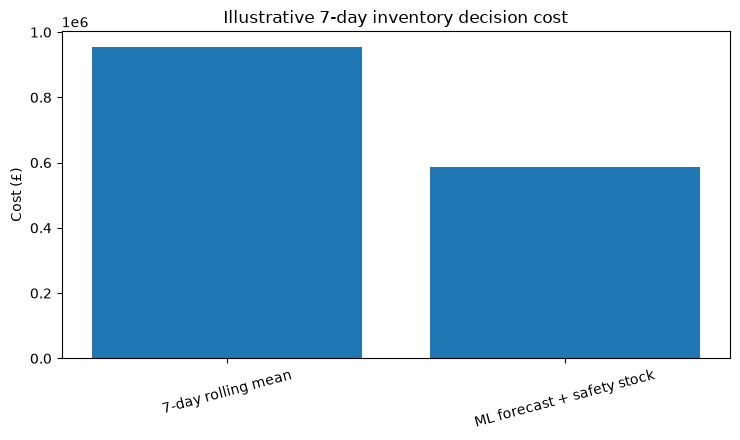

In [15]:
STOCKOUT_COST_PER_UNIT = 4.0
HOLDING_COST_PER_EXCESS_UNIT = 0.05

baseline_cost = (
    sim["baseline_shortage"].sum() * STOCKOUT_COST_PER_UNIT
    + sim["baseline_excess"].sum() * HOLDING_COST_PER_EXCESS_UNIT
)
recommended_cost = (
    sim["recommended_shortage"].sum() * STOCKOUT_COST_PER_UNIT
    + sim["recommended_excess"].sum() * HOLDING_COST_PER_EXCESS_UNIT
)

cost_summary = pd.DataFrame({
    "policy":["7-day rolling mean","ML forecast + safety stock"],
    "illustrative_cost":[baseline_cost, recommended_cost]
}).set_index("policy")
cost_summary["vs_baseline_change"] = (
    cost_summary["illustrative_cost"] / baseline_cost - 1
)

display(cost_summary.style.format({
    "illustrative_cost":"£{:,.2f}",
    "vs_baseline_change":"{:+.2%}"
}))

print(
    f"Simulated cost change from forecast-driven replenishment: "
    f"{(recommended_cost/baseline_cost-1):+.2%}"
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(cost_summary.index, cost_summary["illustrative_cost"])
ax.set_title("Illustrative 7-day inventory decision cost")
ax.set_ylabel("Cost (£)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 11. Final replenishment recommendation table

In [16]:
latest_date = policy["date"].max()
latest = policy.loc[policy["date"] == latest_date].copy()

latest["reorder_point_units"] = np.ceil(latest["recommended_target"]).astype(int)
latest["safety_stock_units"] = np.ceil(latest["safety_stock"]).astype(int)
latest["forecast_daily_units"] = latest["forecast"]

latest["uncertainty_ratio"] = (
    latest["safety_stock"] / (latest["forecast"] * LEAD_TIME_DAYS + 1)
)
latest["priority"] = pd.cut(
    latest["uncertainty_ratio"],
    bins=[-np.inf, 0.20, 0.50, np.inf],
    labels=["Standard","Watch","High uncertainty"]
)

recommendations = latest[[
    "StockCode","Description",
    "forecast_daily_units","safety_stock_units",
    "reorder_point_units","priority"
]].sort_values("reorder_point_units", ascending=False)

print(f"Replenishment recommendations generated for {latest_date.date()}:")
display(recommendations.head(20).style.format({
    "forecast_daily_units":"{:.1f}"
}))

recommendations.to_csv("retail_replenishment_recommendations.csv", index=False)
test_results.to_csv("retail_forecast_test_metrics.csv")
inventory_summary.to_csv("retail_inventory_policy_simulation.csv")

print("Decision artefacts exported.")

Replenishment recommendations generated for 2011-12-09:


,StockCode,Description,forecast_daily_units,safety_stock_units,reorder_point_units,priority
419,22197,POPCORN HOLDER,581.3,878,4947,Watch
959,84879,ASSORTED COLOUR BIRD ORNAMENT,504.0,439,3967,Standard
1079,85099B,JUMBO BAG RED RETROSPOT,100.8,1027,1732,High uncertainty
239,21915,RED HARMONICA IN BOX,63.2,1123,1565,High uncertainty
479,22355,CHARLOTTE BAG SUKI DESIGN,183.0,243,1524,Standard
299,21977,PACK OF 60 PINK PAISLEY CAKE CASES,116.9,610,1429,High uncertainty
179,21212,PACK OF 72 RETROSPOT CAKE CASES,122.0,562,1416,High uncertainty
359,22178,VICTORIAN GLASS HANGING T-LIGHT,51.0,652,1009,High uncertainty
539,22386,JUMBO BAG PINK POLKADOT,45.5,648,967,High uncertainty
839,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,58.3,507,915,High uncertainty


Decision artefacts exported.


## 12. Executive summary

In [17]:
baseline_test = test_results.loc["Seasonal naive (lag 7)"]
champion_test = test_results.loc["SKU champion ensemble"]
baseline_service = inventory_summary.loc["7-day rolling mean","service_level"]
champion_service = inventory_summary.loc["Champion forecast + safety stock","service_level"]

print(f"""
RETAIL DEMAND & INVENTORY EXECUTIVE SUMMARY
-------------------------------------------
Dataset: UCI Online Retail
Modelled SKUs: {panel['StockCode'].nunique()}
SKU selection: repeat-demand replenishable products
Deployment strategy: SKU champion ensemble
Final test WMAPE: {champion_test['WMAPE']:.2%}
Seasonal-naive test WMAPE: {baseline_test['WMAPE']:.2%}
Champion WMAPE change vs naive: {(champion_test['WMAPE']/baseline_test['WMAPE']-1):+.2%}

Baseline simulated service level: {baseline_service:.2%}
Champion + safety-stock service level: {champion_service:.2%}
Illustrative inventory cost change: {(recommended_cost/baseline_cost-1):+.2%}

The notebook connects forecasting to an operational decision:
historical transactions -> leakage-safe demand features -> per-SKU
validation model selection -> forecast uncertainty -> safety stock ->
reorder point -> simulated service and cost.
""")


RETAIL DEMAND & INVENTORY EXECUTIVE SUMMARY
-------------------------------------------
Dataset: UCI Online Retail
Modelled SKUs: 20
SKU selection: repeat-demand replenishable products
Deployment strategy: SKU champion ensemble
Final test WMAPE: 91.68%
Seasonal-naive test WMAPE: 113.91%
Champion WMAPE change vs naive: -19.51%

Baseline simulated service level: 50.00%
Champion + safety-stock service level: 78.98%
Illustrative inventory cost change: -38.63%

The notebook connects forecasting to an operational decision:
historical transactions -> leakage-safe demand features -> per-SKU
validation model selection -> forecast uncertainty -> safety stock ->
reorder point -> simulated service and cost.



### Production roadmap
- hierarchical forecasts across SKU / category / total business levels;
- probabilistic prediction intervals rather than residual-normal approximations;
- supplier-specific lead times and minimum order quantities;
- promotion, price, holiday and marketing calendars;
- lost-sales estimation rather than treating observed sales as unconstrained demand;
- inventory-on-hand and open-purchase-order integration;
- service-level optimisation by product margin / criticality;
- automated champion/challenger re-selection by SKU;
- drift monitoring and forecast backtesting.

### Interview defence
**“I avoided letting one-off wholesale orders dominate the problem by defining a repeat-demand SKU universe. I used a strict chronological split, shifted every historical-demand feature to prevent leakage, compared seasonal naive, Extra Trees and XGBoost, then selected a champion forecaster per SKU using validation data only. Finally I converted forecast uncertainty into safety stock, reorder points and a service/cost simulation.”**